<font size="2"> Student name: Min Xue </font>
<br>
<font size="2"> Student number: 874430 </font>

**<font size="5"> Codes for Assignment 2</font>**

In [1]:
# import relevant packages
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline
import lifelines
import sksurv
import matplotlib.gridspec as gridspec
from sksurv.nonparametric import kaplan_meier_estimator
from lifelines.statistics import logrank_test,pairwise_logrank_test
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
import eli5
from eli5.sklearn import PermutationImportance

In [21]:
# loading data
covid = pd.read_csv('covid_data.csv', low_memory = False)

**<font size="4"> a) Extract the seven columns for analysis</font>**

In [3]:
covid = covid[['age', 'sex', 'date_confirmation','chronic_disease_binary', 'date_death_or_discharge','download_date','outcome']]

In [4]:
# check first 5 rows
display(covid.head().style)

,age,sex,date_confirmation,chronic_disease_binary,date_death_or_discharge,download_date,outcome
0,78,male,2020-02-21,False,2020-02-22,2021-02-22,death
1,61,female,2020-02-14,False,2020-02-17,2021-02-22,discharge
2,66,male,2020-07-02,False,nan,2021-02-22,nan
3,27,female,2020-07-02,False,nan,2021-02-22,nan
4,17,male,2020-07-02,False,nan,2021-02-22,nan


In [5]:
# check the last 5 rows
display(covid.tail().style)

,age,sex,date_confirmation,chronic_disease_binary,date_death_or_discharge,download_date,outcome
572674,52,female,2020-05-17,False,nan,2021-02-22,nan
572675,52,female,2020-05-17,False,nan,2021-02-22,nan
572676,52,female,2020-05-17,False,nan,2021-02-22,nan
572677,52,male,2020-05-17,False,nan,2021-02-22,nan
572678,52,male,2020-05-17,False,nan,2021-02-22,nan


In [6]:
# check information
covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572679 entries, 0 to 572678
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   age                      572679 non-null  int64 
 1   sex                      572679 non-null  object
 2   date_confirmation        572405 non-null  object
 3   chronic_disease_binary   572679 non-null  bool  
 4   date_death_or_discharge  3094 non-null    object
 5   download_date            572679 non-null  object
 6   outcome                  33601 non-null   object
dtypes: bool(1), int64(1), object(5)
memory usage: 26.8+ MB


**<font size="4"> b) Specification explanation</font>**

This part is explained in the report.

**<font size="4"> c) Transform the data to the time-to-event format</font>**

In [7]:
# check unique values and missing values
col_list = covid.columns.to_list()
for col in col_list:
    print(f'variables: {col} \n')
    print('unique values: \n', covid[col].unique())
    print('unique values counts: \n', covid[col].nunique())
    print('missing values counts: \n', covid[col].isna().sum())

variables: age 

unique values: 
 [ 78  61  66  27  17  51  68  26  30  53  35  28  58  33  50  45  24  88
  29  21  52  60  56  79  44  82  25  40  64  84  54  16  34  43   7  69
  47   8  10  55  38  42  62  39  71  36  31   1  48  74  65  46  57  32
  80  73   3   5  22  41  14  70  96  20  63  75   0  12  49  77  18  72
   4  95  37  23  19  94  59  85  91  87  76  67  15   9  13  81  11  86
  83   2  89  93   6  92  97 105  90  99 101  98 102 100 121 104 103 107
 106]
unique values counts: 
 109
missing values counts: 
 0
variables: sex 

unique values: 
 ['male' 'female']
unique values counts: 
 2
missing values counts: 
 0
variables: date_confirmation 

unique values: 
 ['2020-02-21' '2020-02-14' '2020-07-02' '2020-08-02' '2020-02-13'
 '2020-12-02' '2020-10-02' '2020-11-02' '2020-09-02' '2020-02-15'
 '2020-02-16' '2020-02-18' '2020-06-02' '2020-04-02' '2020-02-17'
 '2020-02-22' '2020-02-19' '2020-02-20' '2020-01-25' '2020-01-26'
 '2020-03-02' '2020-01-28' '2020-02-23' nan '2020-

In [8]:
# convert strings and remove the whitespace
covid.outcome = covid.outcome.str.lower()
covid.outcome = covid.outcome.replace(' ','')
covid.outcome.value_counts()

hospitalized                                                                27908
recovered                                                                    3795
died                                                                          916
deceased                                                                      398
discharge                                                                     165
stable condition                                                              109
stable                                                                         97
discharged                                                                     94
death                                                                          45
alive                                                                          37
under treatment                                                                13
dead                                                                            9
severe          

In [9]:
# define death related events
def target_event(var):
    death_events = ['death','died','dead','deceased']
    if any(event in str(var) for event in death_events):
        return '1'
    else:
        return '0'
covid['event'] = covid['outcome'].apply(target_event)
covid['event'] = covid['event'].astype('int').fillna(0)

In [10]:
# check how many fulfilled results
covid['event'].value_counts()

0    571311
1      1368
Name: event, dtype: int64

In [11]:
# calculate Time
covid.date_confirmation = pd.to_datetime(covid.date_confirmation,errors='coerce')
covid.date_death_or_discharge = pd.to_datetime(covid.date_death_or_discharge,errors='coerce')
covid.download_date = covid.download_date.astype('datetime64[ns]')

In [12]:
# calculate time for analysis
def time_for_analysis(start, end):
    return (start - end).days
covid['time'] = (covid.apply(lambda x: time_for_analysis(x.date_confirmation, x.download_date)\
                           if pd.isna(x.date_death_or_discharge)\
                           else time_for_analysis(x.date_confirmation, x.date_death_or_discharge),axis = 1)).abs()

In [13]:
# select none NaN time
time_na = covid.loc[pd.isna(covid['time'])]
covid_new = covid[~covid.time.isin(time_na.time)]
covid_new = covid_new[['age', 'sex','chronic_disease_binary', 'event', 'time']]

In [14]:
# check NaN values
covid_new.isna().sum()

age                       0
sex                       0
chronic_disease_binary    0
event                     0
time                      0
dtype: int64

**<font size="4"> d) Data explanation</font>**

In [15]:
# EDA
covid_new.describe()

,age,event,time
count,572405.000000,572405.000000,572405.000000
mean,45.688383,0.002318,282.065216
std,19.708668,0.048093,73.408390
min,0.000000,0.000000,0.000000
25%,29.000000,0.000000,269.000000
50%,47.000000,0.000000,293.000000
75%,59.000000,0.000000,330.000000
max,121.000000,1.000000,417.000000


In [16]:
# check number of death
covid_new['event'].value_counts()

0    571078
1      1327
Name: event, dtype: int64

In [17]:
# death rates
print('The total death rate basing on the original data:',round(covid['event'].value_counts()[1]/covid['event'].value_counts().sum() * 100, 2))
print('The total death rate basing on the time-to-event data:',round(covid_new['event'].value_counts()[1]/covid_new['event'].value_counts().sum() * 100, 2))

The total death rate basing on the original data: 0.24
The total death rate basing on the time-to-event data: 0.23


Text(0.5, 1.0, 'Distribution for time')

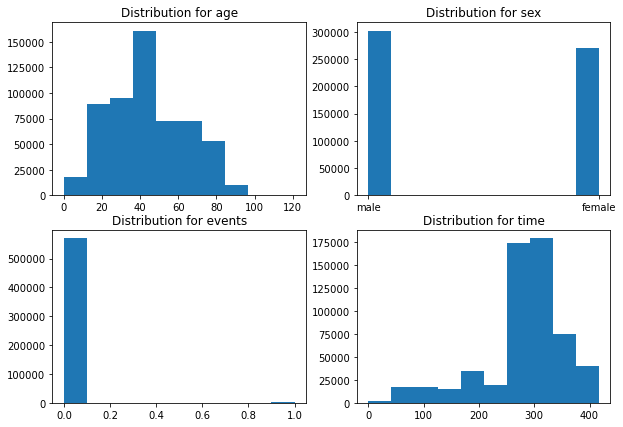

In [18]:
# distribution
cols = covid_new.columns.to_list()

fig=plt.figure(figsize=(10,7))
gs = gridspec.GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax1.hist(covid_new.age)
ax1.set_title('Distribution for age')
ax2.hist(covid_new.sex)
ax2.set_title('Distribution for sex')
ax3.hist(covid_new.event)
ax3.set_title('Distribution for events')
ax4.hist(covid_new.time)
ax4.set_title('Distribution for time')

#### **<font size="4"> e) Survival analysis with Kaplan-Meier estimator</font>**

Text(0.5, 0, 'time $t$')

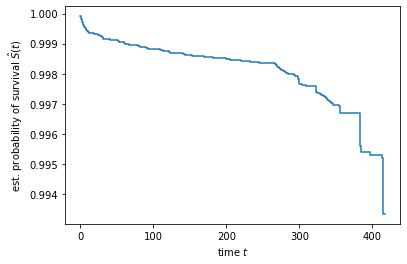

In [22]:
time = covid_new.time
death = covid_new.event.astype('bool')
time, survival_prob = kaplan_meier_estimator(death, time)
plt.step(time, survival_prob, where="post")
plt.ylabel("est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")

**<font size="4"> f) Plot KM curve for female and male genders</font>**

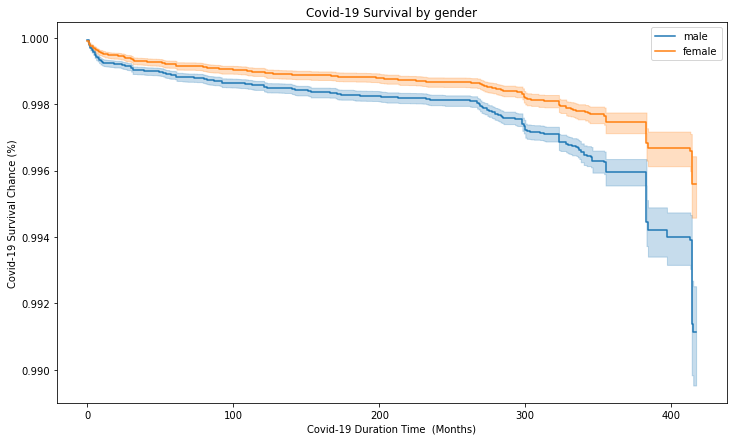

In [23]:
# function for creating Kaplan-Meier curve plots segmented
# by categorical variables
def plot_categorical_survival(feature, t='time', event='event', df=covid_new, ax=None):
    for cat in df[feature].unique():
        idx = df[feature] == cat
        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(df[idx][t], event_observed=df[idx][event], label=cat)
        kmf.plot(ax=ax, label=cat)

# plot by gender
fig_gen, ax_gen = plt.subplots(figsize=(12,7))
plot_categorical_survival(feature='sex', ax=ax_gen)
ax_gen.set_title('Covid-19 Survival by gender')
ax_gen.set_xlabel('Covid-19 Duration Time  (Months)')
ax_gen.set_ylabel('Covid-19 Survival Chance (%)')
plt.show()

**<font size="3"> log-rank test</font>**

In [24]:
# logrank test
# check survival curves for different genders
female = (covid_new["sex"] == "female")
T = covid_new["time"]
E = covid_new["event"]
kmf = lifelines.KaplanMeierFitter()
kmf.fit(T[female], event_observed=E[female])

# for the variable which has only two categories.
covid_gender_results = logrank_test(T[female], T[~female], E[female], E[~female], alpha=.99)
covid_gender_results.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.99
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          60.14 <0.005     46.68

**<font size="4"> g) Plot KM curve for three age groups</font>**

In [25]:
def age_group(age):
    if age <= 40:
        return 'young'
    if 40 < age <=65:
        return 'middle'
    if age > 65:
        return 'old'
covid_new['age_group'] = covid_new['age'].apply(age_group)

In [26]:
# sanity check 
print(covid_new.age_group.value_counts())
print('missing values in age group:', covid_new.age_group.isna().sum())

young     231305
middle    228220
old       112880
Name: age_group, dtype: int64
missing values in age group: 0


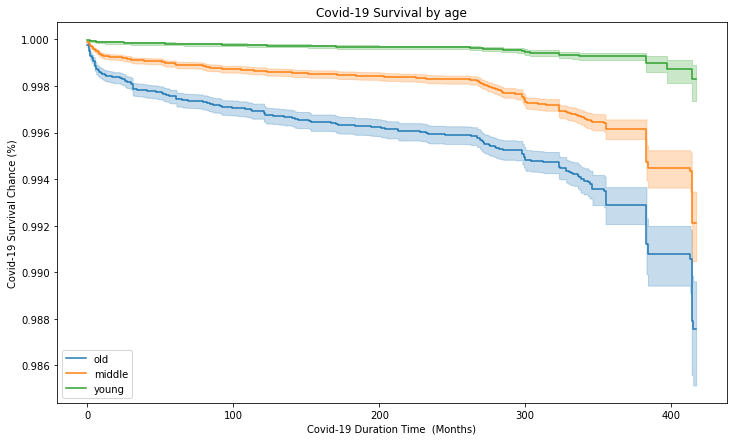

In [27]:
# plot by age group
fig_age, ax_age = plt.subplots(figsize=(12,7))
plot_categorical_survival(feature='age_group', ax=ax_age)
ax_age.set_title('Covid-19 Survival by age')
ax_age.set_xlabel('Covid-19 Duration Time  (Months)')
ax_age.set_ylabel('Covid-19 Survival Chance (%)')
plt.show()

In [28]:
# pairwise logrank test
pairwise_results = pairwise_logrank_test(covid_new['time'],covid_new['age_group'],covid_new['event'])
pairwise_results.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
              test_statistic      p  -log2(p)
middle old            135.38 <0.005    101.53
       young          312.98 <0.005    230.24
old    young          777.44 <0.005    565.94

**<font size="4"> h) Fit and plot a Cox model with sex as the only covariate</font>**

In [29]:
# get binary variables for 'sex'
covid_cox = covid_new[['sex','time','event']]
covid_cox = pd.get_dummies(covid_cox, columns=['sex'], prefix=['sex'], drop_first=True) 
covid_cox.head()

,time,event,sex_male
0,1.0,1,1
1,3.0,0,0
2,235.0,0,1
3,235.0,0,0
4,235.0,0,1


In [30]:
# split the data and train the model
random.seed(10)
covid_train, covid_test = train_test_split(covid_cox,test_size=0.35)
covid_cph = lifelines.CoxPHFitter()
covid_cph.fit(covid_train, duration_col='time', event_col='event', show_progress=False)
covid_cph.print_summary()

<lifelines.CoxPHFitter: fitted with 372063 total observations, 371184 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 372063
number of events observed = 879
   partial log-likelihood = -10882.64
         time fit was run = 2022-03-14 18:53:08 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
sex_male    0.39       1.48       0.07             0.25             0.53                 1.29                 1.69

             z      p   -log2(p)
covariate                       
sex_male  5.60 <0.005      25.51
---
Concordance = 0.54
Partial AIC = 21767.28
log-likelihood ratio test = 32.19 on 1 df
-log2(p) of ll-ratio test = 26.09

<AxesSubplot:xlabel='log(HR) (95% CI)'>

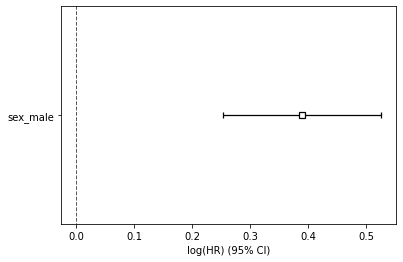

In [31]:
# plot the result
covid_cph.plot()

**<font size="4"> i) Fit and plot a model with sex as a stratify variable and age groups as a covariate.</font>**

In [32]:
# get binary variable for 'sex' and 'age_group'
covid_multi = covid_new[['sex','event','time','age_group']]
covid_multi = pd.get_dummies(covid_multi, columns = ['sex','age_group'],prefix = ['sex','age_group'], drop_first = True)

In [33]:
# split the data and train the new model
covid_multi_train, covid_multi_test = train_test_split(covid_multi, test_size = 0.35)
covid_multi_cph = lifelines.CoxPHFitter()
covid_multi_cph.fit(covid_multi_train, duration_col='time', event_col='event', strata = 'sex_male',show_progress=False)
covid_multi_cph.print_summary()

<lifelines.CoxPHFitter: fitted with 372063 total observations, 371215 right-censored observations>
             duration col = 'time'
                event col = 'event'
                   strata = sex_male
      baseline estimation = breslow
   number of observations = 372063
number of events observed = 848
   partial log-likelihood = -9676.52
         time fit was run = 2022-03-14 18:53:19 UTC

---
                  coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                               
age_group_old     0.69       2.00       0.07             0.55             0.83                 1.73                 2.30
age_group_young  -1.66       0.19       0.13            -1.91            -1.41                 0.15                 0.24

                     z      p   -log2(p)
covariate                               
age_group_old     9.61 <0.005      70.20
age_group_young -12.93 <0.005     124.66
---
Concordance = 0.71
Partial AIC = 19357.05
log-likelihood ratio test = 506.02 on 2 df
-log2(p) of ll-ratio test = 365.02

<AxesSubplot:xlabel='log(HR) (95% CI)'>

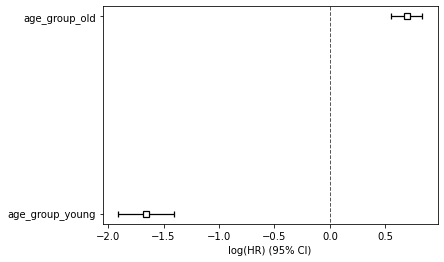

In [34]:
# plot the result
covid_multi_cph.plot()

**<font size="4"> j) Check proportional hazard assumption</font>**

Text(0, 0.5, 'log(-log(Startup Survival Chance (%)))')

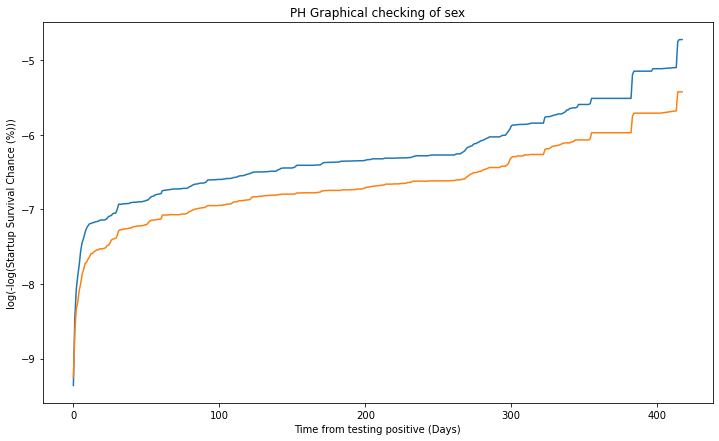

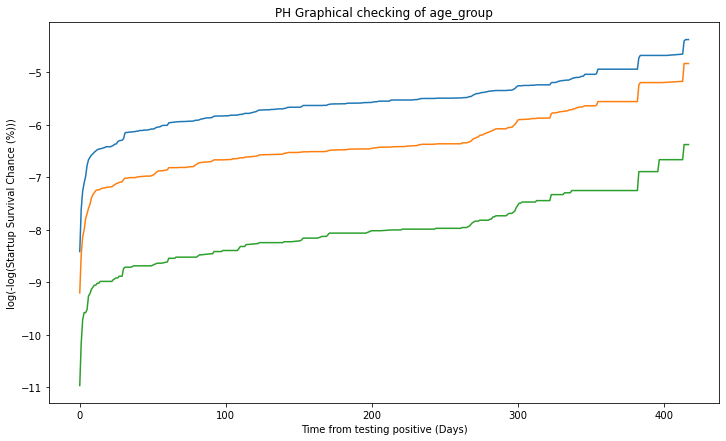

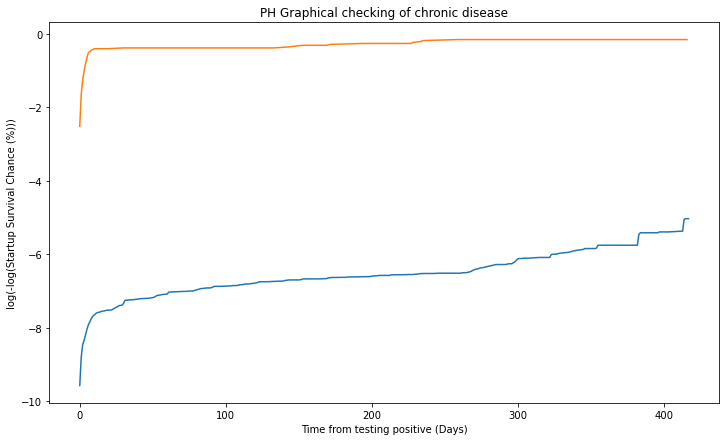

In [47]:
# quick check visually log(-log(surv)) vs time

def graphical_checking_PH(feature, time='time', event='event', df=covid_new, ax=None):
    for cat in df[feature].unique():
        idx = df[feature] == cat
        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(df[idx][time], event_observed=df[idx][event], label=cat)
        kmf_surv = kmf.survival_function_.reset_index()
        plt.plot(kmf_surv.timeline,np.log(-np.log(kmf_surv[cat])),label = cat)

# plot by sex
fig, ax = plt.subplots(figsize=(12,7))
graphical_checking_PH(feature='sex', ax=ax)
ax.set_title('PH Graphical checking of sex')
ax.set_xlabel('Time from testing positive (Days)')
ax.set_ylabel('log(-log(Startup Survival Chance (%)))')

# plot by age group
fig, ax = plt.subplots(figsize=(12,7))
graphical_checking_PH(feature='age_group', ax=ax)
ax.set_title('PH Graphical checking of age_group')
ax.set_xlabel('Time from testing positive (Days)')
ax.set_ylabel('log(-log(Startup Survival Chance (%)))')

# plot by chronic_disease_binary
fig, ax = plt.subplots(figsize=(12,7))
graphical_checking_PH(feature='chronic_disease_binary', ax=ax)
ax.set_title('PH Graphical checking of chronic disease')
ax.set_xlabel('Time from testing positive (Days)')
ax.set_ylabel('log(-log(Startup Survival Chance (%)))')

**<font size="4"> k) Apply random forest tree with scikit-survival Python package</font>**

In [42]:
def convert_to_stru_array(df,time_column, event_column):
    """
    This function is conver time and event to structured array which is required in scikit-survival Python package.
    
    Inputs:
    df:         the input datafram
    time_column : the column which has TIME information.
    event_column: the column which has EVENT information.
    
    Output:
    X_df: dataframe after removing time and event columns
    Y_stru_array: structured array which is like (event, time)
    """

    #remove the time and event columns from the original dataframe
    X_df = df.drop(columns = [time_column, event_column])
    
    #extract time and event columns
    Y_df = df[[event_column,time_column]]
    Y_np = Y_df.to_numpy()

    #change it to structured array
    Y_recarray   = np.core.records.fromarrays(Y_np.transpose(), dtype=np.dtype([(event_column, np.bool_), (time_column, np.float32)]))
    Y_stru_array = np.array(Y_recarray)
    
    return X_df,Y_stru_array


In [61]:
# get binary variables for all non-binary variables
covid_all = covid_new[['sex','chronic_disease_binary','event','time','age_group']]
covid_all = pd.get_dummies(covid_all, columns=['sex','age_group','chronic_disease_binary'], prefix = ['sex','age_group','chronic_disease'], drop_first=True) 

In [62]:
# split data for models
covid_all_train, covid_all_test = train_test_split(covid_all, test_size = 0.35)

In [63]:
# training and test data for X and y
X_train_cox, Y_train_cox = convert_to_stru_array(covid_all_train,'time', 'event')
X_test_cox, Y_test_cox = convert_to_stru_array(covid_all_test,'time', 'event')

**<font size="3"> Random survival Forest</font>**

In [64]:
# model construction
random_state = 20
sksurv_rsf = RandomSurvivalForest(n_estimators=100,
                           min_samples_split=10,
                           min_samples_leaf=15,
                           max_features="sqrt",
                           n_jobs=-1,
                           random_state=random_state)
sksurv_rsf.fit(X_train_cox, Y_train_cox)

RandomSurvivalForest(max_features='sqrt', min_samples_leaf=15,
                     min_samples_split=10, n_jobs=-1, random_state=20)

In [65]:
sksurv_rsf.score(X_test_cox, Y_test_cox)

0.7344326177261478

**<font size="3"> Permutation-based Feature Importance </font>**

In [66]:
perm = PermutationImportance(sksurv_rsf, n_iter=3, random_state=random_state)
perm.fit(X_test_cox, Y_test_cox)
eli5.show_weights(perm, feature_names=X_train_cox.columns.tolist())

Weight,Feature
0.0704 ± 0.0122,age_group_young
0.0701 ± 0.0074,age_group_old
0.0178 ± 0.0000,chronic_disease_True
0.0113 ± 0.0084,sex_male
